In [1]:
import pandas as pd
import numpy as np
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [3]:
full = pd.read_csv('../Soyun_EDA/final_eda.csv')

In [4]:
received = (
    full.loc[full['event'] == 'offer received', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_received'})
    .sort_values(['customer_id', 'offer_id', 't_received'])
    .reset_index(drop=True)
)
viewed = (
    full.loc[full['event'] == 'offer viewed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_viewed'})
    .sort_values(['customer_id', 'offer_id', 't_viewed'])
    .reset_index(drop=True)
)
completed = (
    full.loc[full['event'] == 'offer completed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_completed'})
    .sort_values(['customer_id', 'offer_id', 't_completed'])
    .reset_index(drop=True)
)

# 같은 고객, 같은 오퍼를 수신 받았을 때 instance_id 각각 부여 (모두 1로, 똑같은 객체가 들어오면 그때 2)
received['instance_id'] = received.groupby(['customer_id', 'offer_id']).cumcount() + 1

portfolio_dur = (
    full[['offer_id', 'duration']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
received = received.merge(portfolio_dur, on='offer_id', how='left')

# [경계조건] t_expire = t_received + duration * 24
# - transcript.time 단위: 시간(hour), portfolio.duration 단위: 일(day) → *24 변환
# - 경계: t_received <= event_time <= t_expire (양 끝 포함, closed interval)
#   → 수신 시각과 만료 시각 정확히 일치하는 이벤트도 유효로 처리
#   → strict (<) 버전은 사용하지 않음 (수신 즉시 이벤트 발생 사례 존재)
received['t_expire'] = received['t_received'] + received['duration'] * 24

recv_keys = received[['customer_id', 'offer_id', 't_received', 'instance_id', 't_expire']]

In [5]:
def interval_join(events_df, event_time_col):
    # [경계조건] t_received <= t_event <= t_expire (양 끝 포함)
    # [ambiguous match 처리 규칙]
    #   - 같은 이벤트가 복수의 수신 구간에 걸칠 경우(ambiguous_match=1),
    #     t_received가 가장 최근인(=직전에 수신된) instance를 선택
    #   - 근거: 가장 최근 수신 오퍼에 반응했을 가능성이 가장 높다고 가정
    events_df = events_df.copy()
    events_df['_row_id'] = range(len(events_df))
    merged = events_df.merge(recv_keys, on=['customer_id', 'offer_id'], how='left') # 겹치는게 엄청 많을 거임 on 조건이 인스턴스 조건 뿐이므로!
    valid = merged[ # 하지만 여기서 필터링을 걸어줘서 구간 내에 포함되는 view와 receive 행만 추출
        (merged['t_received'] <= merged[event_time_col]) &
        (merged[event_time_col] <= merged['t_expire'])
    ].copy()
    match_cnt = ( # 같은 view 행에서 몇개의 receive 행이 연결되었는지 카운트
        valid.groupby('_row_id')['instance_id']
        .count().reset_index(name='match_count')
    )
    valid = valid.merge(match_cnt, on='_row_id')
    valid['ambiguous_match'] = (valid['match_count'] > 1).astype(int)
    valid = (
        valid.sort_values('t_received', ascending=False) # 같은 구간내에 여러개의 수신 인스턴스가 존재한다면 최근 수신된 인스턴스 선택
        .drop_duplicates(subset='_row_id', keep='first')
        .drop(columns='_row_id')
    )
    return valid

view_map = interval_join(viewed, 't_viewed')
comp_map = interval_join(completed, 't_completed')


In [6]:
view_map = view_map.sort_values(by=['customer_id','offer_id'])
view_map

,customer_id,offer_id,t_viewed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,informational,336,1,432.0,1,0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,informational,168,1,240.0,1,0
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,456,bogo,408,1,528.0,1,0
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,540,discount,504,1,744.0,1,0
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,630,bogo,576,2,696.0,1,0
...,...,...,...,...,...,...,...,...,...
58929,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,582,discount,576,3,744.0,1,0
58928,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
58926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,354,discount,336,1,504.0,1,0
58930,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,534,bogo,504,1,672.0,1,0


In [7]:
comp_map = comp_map.sort_values(by=['customer_id','offer_id'])
comp_map

,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,576,1,744.0,1,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,bogo,408,1,528.0,1,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,discount,504,1,744.0,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,discount,408,1,648.0,1,0
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,discount,168,1,336.0,1,0
...,...,...,...,...,...,...,...,...,...
35373,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,576,3,744.0,2,1
35371,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
35369,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,discount,336,1,504.0,1,0
35374,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,504,1,672.0,1,0


In [8]:
# == [품질 체크 1] 이벤트 중복 매핑 확인 ==
dup_view_map = view_map[view_map.duplicated()]
print(f"중복건: {len(dup_view_map)}개") # 중복 없음

dup_comp_map = comp_map[comp_map.duplicated()]
print(f"중복건: {len(dup_comp_map)}개") # 중복 존재

중복건: 0개
중복건: 397개


In [9]:
n_no_match_v = len(viewed) - len(view_map)
n_no_match_c = len(completed) - len(comp_map)
n_ambig_v = view_map['ambiguous_match'].sum()
n_ambig_c = comp_map['ambiguous_match'].sum()
print(f"열람: 유효 구간 밖 {n_no_match_v:,}건 / ambiguous {n_ambig_v:,}건") # 한 view 행이 여러 receive 행과 연결될 수 있는 모호한 건 수
print(f"완료: 유효 구간 밖 {n_no_match_c:,}건 / ambiguous {n_ambig_c:,}건") # 한 complete 행이 여러 receive 행과 연결될 수 있는 모호한 건 수

view_summary = (
    view_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_viewed=('t_viewed', 'min'),
        last_viewed=('t_viewed', 'max'),
        view_count=('t_viewed', 'count'),
        view_ambiguous=('ambiguous_match', 'max')
    )
)

comp_summary = (
    comp_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_completed=('t_completed', 'min'),
        last_completed=('t_completed', 'max'),
        complete_count=('t_completed', 'count'),
        comp_ambiguous=('ambiguous_match', 'max')
    )
)

열람: 유효 구간 밖 1,158건 / ambiguous 2,339건
완료: 유효 구간 밖 0건 / ambiguous 1,776건


In [10]:
view_summary[view_summary['view_count']>1]

,customer_id,offer_id,instance_id,first_viewed,last_viewed,view_count,view_ambiguous


In [11]:
comp_summary[(comp_summary['complete_count']>1)&(comp_summary['first_completed']!=comp_summary['last_completed'])]

,customer_id,offer_id,instance_id,first_completed,last_completed,complete_count,comp_ambiguous
294,0246e7cc7a3d4a98a940cb13776b5b55,fafdcd668e3743c1bb461111dcafc2a4,2,582,624,2,1
505,041fd7c6b796430a867c4e03d2ff8f4d,0b1e1539f2cc45b7b9fa7c272da2e1d7,3,648,702,2,1
745,05e6bcb70fe14e0da4730527ca35a4ae,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,510,540,2,1
754,05f4d69f73024172a23a350e611166b4,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,414,432,2,1
904,072290a7410e49d3a1e45a89c92c58f3,2298d6c36e964ae4a3e7e9706d1fb8c2,2,432,468,2,1
...,...,...,...,...,...,...,...
30753,edc7b04392144da9979f3077095f268a,fafdcd668e3743c1bb461111dcafc2a4,3,474,498,2,1
31489,f3934f05d51f47c7a470661cbb774075,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,456,462,2,1
31996,f74033a8c6834303bd1b3ef0c98d11d8,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,576,714,2,1
31999,f7465d18ba7f4e43b99ccabf141d421d,2906b810c7d4411798c6938adc9daaa5,3,504,594,2,1


In [12]:
# == [품질 체크 2] 이벤트 중복 매핑 & tie-break 확인 ==

# 1. 한 이벤트가 여러 instance에 중복 매핑되지 않는지
dup_view = view_summary.duplicated().sum()
dup_comp = comp_summary.duplicated().sum()
print(f"[중복 매핑] view_summary: {dup_view}건 / comp_summary: {dup_comp}건 (0이어야 정상)")
assert dup_view == 0, f'view_map 중복 매핑 {dup_view}건 존재'
assert dup_comp == 0, f'comp_summary 중복 매핑 {dup_comp}건 존재'

# 2. ambiguous match 건수 확인 (tie-break: 최근 t_received 기준 1개 선택)
ambig_v = view_summary['view_ambiguous'].sum()
ambig_c = comp_summary['comp_ambiguous'].sum()
print(f"[Ambiguous match] view: {ambig_v:,}건 / comp: {ambig_c:,}건 → 최근 수신 instance 선택")

print("✓ 중복 매핑 체크 통과")

"""
[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택

✓ 중복 매핑 체크 통과
"""

[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택
✓ 중복 매핑 체크 통과


'\n[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)\n[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택\n\n✓ 중복 매핑 체크 통과\n'

In [13]:
funnel_instance = (
    received.merge(view_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
            .merge(comp_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
)

funnel_instance['gap_to_first_view'] = funnel_instance['first_viewed'] - funnel_instance['t_received']
funnel_instance['gap_to_first_complete'] = funnel_instance['first_completed'] - funnel_instance['t_received']
funnel_instance['is_viewed'] = funnel_instance['first_viewed'].notna()
funnel_instance['is_completed'] = funnel_instance['first_completed'].notna()
funnel_instance['completed_without_prior_view'] = (
    (funnel_instance['is_completed'] & ~funnel_instance['is_viewed'])
    | (funnel_instance['first_completed'] < funnel_instance['first_viewed'])  # 완료가 열람보다 먼저인 경우
)
funnel_instance['completed_with_prior_view'] = (
    funnel_instance['is_completed'] & funnel_instance['is_viewed']
    & (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
)
funnel_instance['concurr']=(funnel_instance['first_viewed'] == funnel_instance['first_completed'])

# prior view가 있고 시간 순서가 맞는 경우에만 gap 계산 (시간 순서 확실한 것만)
mask = (
    funnel_instance['first_viewed'].notna() &
    funnel_instance['first_completed'].notna() &
    (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
)
funnel_instance['gap_first_view_to_first_complete'] = np.where(
    mask,
    funnel_instance['first_completed'] - funnel_instance['first_viewed'],
    np.nan
)

In [14]:
first_viewed_instance = ( # 같은 오퍼를 여러번 받은 경우 이벤트를 '열람'한 오퍼
    funnel_instance[funnel_instance['is_viewed']]
    .groupby(['customer_id','offer_id'])['instance_id']
    .min()
    .reset_index(name = 'first_viewed_instance')
)

first_viewed_instance['first_viewed_instance'].value_counts() # 경향만 보는 것으로!

first_viewed_instance
1    47024
2     1146
3       42
4        1
Name: count, dtype: int64

In [15]:
funnel_instance.sort_values(by=['customer_id','offer_id','instance_id'])

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,concurr,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,False,False,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,False,False,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,True,True,False,True,False,30.0
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,True,True,False,False,True,NaN
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,True,True,True,False,False,NaN
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,True,True,True,False,False,NaN


In [16]:
funnel_instance.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       76277 non-null  str    
 1   offer_id                          76277 non-null  str    
 2   t_received                        76277 non-null  int64  
 3   offer_type                        76277 non-null  str    
 4   instance_id                       76277 non-null  int64  
 5   duration                          76277 non-null  float64
 6   t_expire                          76277 non-null  float64
 7   first_viewed                      56567 non-null  float64
 8   last_viewed                       56567 non-null  float64
 9   view_count                        56567 non-null  float64
 10  view_ambiguous                    56567 non-null  float64
 11  first_completed                   33101 non-null  float64
 12  last_completed 

In [17]:
print(f"전체 오퍼 received 인스턴스 수: {len(funnel_instance):,}건")
print("[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance['gap_to_first_view'].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance['gap_to_first_complete'].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("[ 퍼널 요약 ]")
print(f"  Viewed rate     : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate  : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람: {funnel_instance['completed_without_prior_view'].mean()*100:.1f}%")

전체 오퍼 received 인스턴스 수: 76,277건
[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 24.4시간 (1.0일)
  중앙값 : 12.0시간 (0.5일)
  6시간 내 열람 : 38.5%
  24시간 내 열람: 67.3%
  48시간 내 열람: 85.2%
[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%
[ 퍼널 요약 ]
  Viewed rate     : 74.2%
  Completed rate  : 43.4%
  완료했지만 미열람: 12.9%


In [18]:
funnel_instance.head(10)

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,concurr,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,False,False,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,False,False,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,False,False,NaN
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,bogo,1,5.0,288.0,216.0,216.0,1.0,0.0,NaN,NaN,NaN,NaN,48.0,NaN,True,False,False,False,False,NaN
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,bogo,2,5.0,696.0,630.0,630.0,1.0,0.0,NaN,NaN,NaN,NaN,54.0,NaN,True,False,False,False,False,NaN
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,408,discount,1,10.0,648.0,432.0,432.0,1.0,0.0,576.0,576.0,1.0,0.0,24.0,168.0,True,True,False,True,False,144.0
8,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,168,discount,1,7.0,336.0,186.0,186.0,1.0,0.0,252.0,252.0,1.0,0.0,18.0,84.0,True,True,False,True,False,66.0
9,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,0,informational,1,4.0,96.0,6.0,6.0,1.0,0.0,NaN,NaN,NaN,NaN,6.0,NaN,True,False,False,False,False,NaN


In [19]:
funnel_instance.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 'first_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 'first_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_first_view', 'gap_to_first_complete',
       'is_viewed', 'is_completed', 'completed_without_prior_view',
       'completed_with_prior_view', 'concurr',
       'gap_first_view_to_first_complete'],
      dtype='str')

In [20]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [21]:
print("Viewed rate:", funnel_instance['is_viewed'].mean()) # 오퍼 노출은 잘 된다 (0.74)
print("Completed rate:", funnel_instance['is_completed'].mean()) # 전환에서 크게 떨어진다 (0.43)
print("Completed without prior view:", (funnel_instance['completed_without_prior_view']).mean()) # prior view 로그가 확인되지 않은 완료

Viewed rate: 0.7415996958454055
Completed rate: 0.4339578116601335
Completed without prior view: 0.12892483972888288


In [22]:
# 중복확인
funnel_instance[['customer_id','offer_id','instance_id']].duplicated().sum()

np.int64(0)

In [23]:
# --- 5대 지표 계산 함수 ---
def funnel_metrics(df, group_col: str = "offer_type"):
    return (
        df.groupby(group_col)
        .agg(
            received            = ("instance_id",                  "count"),
            viewed              = ("is_viewed",                    "sum"),
            completed           = ("is_completed",                 "sum"),
            aware_completed     = ("completed_with_prior_view",    "sum"),
            non_aware_completed = ("completed_without_prior_view", "sum"),
        )
        .assign(
            view_rate     = lambda d: d["viewed"]              / d["received"],
            complete_rate = lambda d: d["completed"]           / d["received"],
            view_cvr      = lambda d: d["aware_completed"]     / d["viewed"],
            eff_cvr       = lambda d: d["aware_completed"]     / d["completed"],
            no_eff_cvr    = lambda d: d["non_aware_completed"] / d["completed"],
        )
        .reset_index()
    )


In [24]:
display(funnel_metrics(funnel_instance, 'offer_type')
        .set_index('offer_type')
        .style.format({
            'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
            'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
            'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
            'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
        }))


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
offer_type,,,,,,,,,,
bogo,"30,499","25,250","15,501","9,413","4,560",82.8%,50.8%,37.3%,60.7%,29.4%
discount,"30,543","21,370","17,600","11,135","5,274",70.0%,57.6%,52.1%,63.3%,30.0%
informational,"15,235","9,947",0,0,0,65.3%,0.0%,0.0%,nan%,nan%


In [25]:
funnel_instance.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,concurr,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,False,False,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,False,False,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,False,False,NaN


In [26]:
# 이후 셀 참조명 통일 (first_ → 단축명) + completed_funnel_instance 재생성
funnel_instance = funnel_instance.rename(columns={
    'first_viewed':                         't_viewed',
    'first_completed':                      't_completed',
    'gap_to_first_view':                    'gap_to_view',
    'gap_to_first_complete':                'gap_to_complete',
    'gap_first_view_to_first_complete':     'gap_view_to_complete'
})
completed_funnel_instance = funnel_instance[funnel_instance['is_completed']].copy()

In [27]:
funnel_instance.to_csv('../Soyun_EDA/funnel_instance.csv', index=False)

### 퍼널 인스턴스 데이터프레임 생성 완료 (인스턴스별)
### -> 다음 : 오퍼와 고객 정보 포함한 데이터프레임 생성

In [28]:
full = pd.read_csv('../Soyun_EDA/final_eda.csv')
funnel = pd.read_csv('../Soyun_EDA/funnel_instance.csv')

데이터 병합 시 validate 파라미터 값
- 'm:1' → 왼쪽은 중복 가능, 오른쪽은 반드시 unique
- '1:1' → 양쪽 모두 unique
- '1:m' → 왼쪽 unique, 오른쪽 중복 가능

In [29]:
# offer_id가 unique여야 하므로 validate='m:1' 검사
offer = ( # distinct offer_id
    full[['offer_id', 'reward', 'difficulty',
          'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
funnel = funnel.merge(offer, on='offer_id', how='left', validate='m:1')

# customer_id가 unique여야 하므로 validate='m:1' 검사
cust_attr = ( # distinct customer_id
    full[['customer_id', 'gender', 'age_group', 'income_group',
          'join_year', 'join_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)

print(f"병합 전 퍼널 데이터 행 개수: {len(funnel)}")
funnel = funnel.merge(cust_attr, on='customer_id', how='left', validate='m:1')
print(f"병합 후 퍼널 데이터 행 개수: {len(funnel)}") # 데이터 증폭 미발생 확인 완료

병합 전 퍼널 데이터 행 개수: 76277
병합 후 퍼널 데이터 행 개수: 76277


In [30]:
funnel.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,concurr,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,False,False,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,False,False,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,False,False,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,False,False,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,False,False,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [31]:
funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   76277 non-null  str    
 1   offer_id                      76277 non-null  str    
 2   t_received                    76277 non-null  int64  
 3   offer_type                    76277 non-null  str    
 4   instance_id                   76277 non-null  int64  
 5   duration                      76277 non-null  float64
 6   t_expire                      76277 non-null  float64
 7   t_viewed                      56567 non-null  float64
 8   last_viewed                   56567 non-null  float64
 9   view_count                    56567 non-null  float64
 10  view_ambiguous                56567 non-null  float64
 11  t_completed                   33101 non-null  float64
 12  last_completed                33101 non-null  float64
 13  complete_cou

In [32]:
# === [품질 체크 3] informational offer completed 여부 ===
info_completed = funnel[
    (funnel['offer_type'] == 'informational') & funnel['is_completed']
]
print(f"[Informational completed] {len(info_completed)}건 (0이어야 정상)")
assert len(info_completed) == 0, f'informational offer에 completed {len(info_completed)}건 존재'
print("✓ informational completed 체크 통과")

[Informational completed] 0건 (0이어야 정상)
✓ informational completed 체크 통과


In [33]:
print("gap_to_view < 0:", (funnel['gap_to_view'] < 0).sum())
print("gap_to_complete < 0:", (funnel['gap_to_complete'] < 0).sum())


gap_to_view < 0: 0
gap_to_complete < 0: 0


### 어떤 오퍼를 보내야 하는가 - 오퍼 종류에 대한 분석 


In [34]:
colors_main = ['#00704A', '#CBA258', '#1E3932', '#D4E9E2', '#006241', '#F2C75C']

In [ ]:
# 전체 퍼널 요약
print("[ 전체 오퍼 유형별 5대 지표 ]")
display(funnel_metrics(funnel, 'offer_type')
        .set_index('offer_type')
        .style.format({
            'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
            'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
            'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
            'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
        }))

# bogo + discount 합산 핵심 지표 출력
conv_mask = funnel['offer_type'].isin(['bogo', 'discount'])
bd = funnel[conv_mask]
view_cvr_bd = bd['completed_with_prior_view'].sum() / bd['is_viewed'].sum()
print(f"\n[bogo+discount] 열람→완료(view_cvr): {view_cvr_bd:.1%}")


In [ ]:
# bogo / discount 전환율 비교 (informational 제외)
bg_vs_disc = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()

display(funnel_metrics(bg_vs_disc, 'offer_type')
        .set_index('offer_type')
        .style.format({
            'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
            'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
            'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
            'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
        }))


In [35]:
from scipy import stats

# bogo vs discount 전환율 차이 검정 (chi-square)
for metric, col in [('수신→열람', 'is_viewed'), ('수신→완료(인지)', 'completed_with_prior_view')]:
    ct = pd.crosstab(bg_vs_disc['offer_type'], bg_vs_disc[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"[{metric}] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
    print(f"  → {'유의미한 차이 있음 (p<0.05)' if p < 0.05 else '유의미한 차이 없음'}")


[수신→열람] chi2=1389.8, p=3.40e-304, dof=1
  → 유의미한 차이 있음 (p<0.05)
[수신→완료(인지)] chi2=213.6, p=2.30e-48, dof=1
  → 유의미한 차이 있음 (p<0.05)


In [ ]:
from scipy import stats

bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()

# --- reward 크기별 5대 지표 ---
print("[ reward 크기별 지표 ]")
display(bd.groupby(['offer_type', 'reward'])
         .agg(
             received  = ('instance_id',            'count'),
             viewed    = ('is_viewed',               'sum'),
             aware_comp= ('completed_with_prior_view','sum'),
         )
         .assign(view_cvr=lambda d: d['aware_comp'] / d['viewed'])
         .style.format({'received': '{:,}', 'viewed': '{:,}', 'aware_comp': '{:,}', 'view_cvr': '{:.1%}'}))

# --- ROI (reward ÷ difficulty) vs view_cvr — discount만 유효 ---
# bogo는 reward=difficulty 구조라 ROI가 항상 1.0 → 분산 없어 분석 불가
bd['roi'] = bd['reward'] / bd['difficulty']
print("[ ROI(reward/difficulty)별 지표 ]")
display(bd.groupby(['offer_type', 'roi'])
         .agg(
             received  = ('instance_id',            'count'),
             viewed    = ('is_viewed',               'sum'),
             aware_comp= ('completed_with_prior_view','sum'),
         )
         .assign(view_cvr=lambda d: d['aware_comp'] / d['viewed'])
         .style.format({'received': '{:,}', 'viewed': '{:,}', 'aware_comp': '{:,}', 'view_cvr': '{:.1%}'}))

print("[ ROI ↔ view_cvr 스피어만 상관 (discount만 유효) ]")
disc = bd[bd['offer_type'] == 'discount']
r, p = stats.spearmanr(disc['roi'], disc['completed_with_prior_view'].astype(int))
print(f"  discount: r={r:.3f}, p={p:.2e}")
print(f"  → {'유의미한 관계 있음' if p < 0.05 else 'ROI 단독으로 view_cvr 설명 어려움 — difficulty/reward 개별 분석 권장'}")
print(f"  bogo: ROI 분산 없음(항상 1.0) → 스피어만 검정 불가")


In [ ]:
from scipy import stats

bogo = funnel[funnel['offer_type'] == 'bogo'].copy()

# 난이도별 view_cvr
print("[ BOGO 난이도별 지표 ]")
display(bogo.groupby('difficulty')
         .agg(
             received  = ('instance_id',            'count'),
             viewed    = ('is_viewed',               'sum'),
             aware_comp= ('completed_with_prior_view','sum'),
         )
         .assign(view_cvr=lambda d: d['aware_comp'] / d['viewed'])
         .style.format({'received': '{:,}', 'viewed': '{:,}', 'aware_comp': '{:,}', 'view_cvr': '{:.1%}'}))

# 난이도가 view_cvr에 유의미한 영향을 주는지 — 카이제곱 독립성 검정
ct = pd.crosstab(bogo['difficulty'], bogo['completed_with_prior_view'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"[난이도 × 완료 여부] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
print(f"→ {'난이도와 view_cvr 간 유의미한 관계 있음 (p<0.05)' if p < 0.05 else '유의미한 관계 없음'}")


#### bogo가 discount보다 난이도 민감도가 더 높은가-> 난이도 상승 효과가 더 크게 완료율을 떨어뜨리는가

In [38]:
import statsmodels.formula.api as smf

# bogo / discount만 사용
bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()
bd['is_bogo'] = (bd['offer_type'] == 'bogo').astype(int)
bd['aware_completed'] = (bd['is_completed'] & bd['completed_with_prior_view']).astype(int)

# 로지스틱 회귀: aware_completed ~ difficulty + is_bogo + difficulty:is_bogo
model = smf.logit('aware_completed ~ difficulty * is_bogo', data=bd).fit(disp=False)
display(model.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|']])


,Coef.,Std.Err.,z,P>|z|
Intercept,0.899562,0.033743,26.659084,1.404358e-156
difficulty,-0.129458,0.002946,-43.938577,0.000000e+00
is_bogo,-1.604900,0.051614,-31.094311,2.875188e-212
difficulty:is_bogo,0.115939,0.005769,20.098265,7.641967e-90


### -로지스틱 통계 분석 결과-

- difficulty:is_bogo p≈0 (7.64e-90) < 0.05, 계수 +0.116 (양수)<br>
<span style="color:#FF5733">**통계적으로 유의함**</span><br>

- difficulty 계수(-0.129): discount 기준으로 난이도 1 오를 때 로그오즈 -0.129 감소
- difficulty:is_bogo 계수(+0.116): bogo는 거기에 +0.116 더해져 → bogo 난이도 효과 = -0.129 + 0.116 = **-0.013** (거의 없음)
- 즉, **난이도에 더 민감한 건 discount** — bogo는 난이도가 올라도 완료율이 거의 변하지 않음

> 오즈(odds) = 완료할 확률 / 완료 안 할 확률

- 로그오즈 = log(오즈) → 로지스틱 회귀의 계수 단위

직관적으로 이해하기:
- 로그오즈가 음수로 커질수록 → 완료 확률이 낮아짐
- 로그오즈가 양수로 커질수록 → 완료 확률이 높아짐

**머신러닝 로지스틱 회귀 — 예측 모델**

- 목적: 새 데이터에 대한 정확한 예측
- 그래서 train/test split, 교차검증, 정확도/AUC 평가가 필요
- 계수 자체보다 모델 성능이 중요

**통계적 로지스틱 회귀 (지금 쓴 것) — 관계 검증**

- 목적: "난이도가 완료율에 영향을 미치는가, bogo와 discount 간에 그 영향이 다른가"를 검증
- train/test 불필요 — 전체 데이터로 계수와 p값을 추정
- 계수(log-odds)와 p값이 핵심, 예측 성능은 관심 없음


In [39]:
import numpy as np
np.exp(-0.072)  # difficulty 1 증가 시 오즈가 몇 배?
# → 0.930 → 난이도 1 오를 때 완료 오즈가 7% 감소


np.float64(0.9305308958112057)

In [ ]:
# 채널 수 × 오퍼 유형별 5대 지표
bd_tmp = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()
display(bd_tmp.groupby(['channel_count', 'offer_type'])
         .agg(
             received  = ('instance_id',            'count'),
             viewed    = ('is_viewed',               'sum'),
             aware_comp= ('completed_with_prior_view','sum'),
         )
         .assign(view_cvr=lambda d: d['aware_comp'] / d['viewed'])
         .style.format({'received': '{:,}', 'viewed': '{:,}', 'aware_comp': '{:,}', 'view_cvr': '{:.1%}'}))


In [41]:
from scipy import stats

# 채널 수별 완료율 차이 — chi-square (독립성 검정)
# bogo, discount만 (informational 완료 없음)
bd_ch = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()
bd_ch['aware_completed'] = bd_ch['is_completed'] & bd_ch['completed_with_prior_view']
ct_ch = pd.crosstab(bd_ch['channel_count'], bd_ch['aware_completed'])
chi2, p, dof, _ = stats.chi2_contingency(ct_ch)
print(f"[채널 수 × 완료 여부] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
print(f"→ {'채널 수와 완료율 간 유의미한 관계 있음 (p<0.05)' if p < 0.05 else '유의미한 관계 없음'}")

# chi-square dof > 1이면 어떤 방향인지 스피어만으로 보완 (순서형이므로 pairwise보다 적절)
r, p_sp = stats.spearmanr(bd_ch['channel_count'], bd_ch['aware_completed'].astype(int))
print(f"채널 수 ↔ 완료율 스피어만: r={r:.3f}, p={p_sp:.2e}")
print(f"→ {'채널이 많을수록 완료율 높음' if r > 0 and p_sp < 0.05 else '채널이 많을수록 완료율 낮음' if r < 0 and p_sp < 0.05 else '유의미한 방향성 없음'}")


[채널 수 × 완료 여부] chi2=3156.0, p=0.00e+00, dof=2
→ 채널 수와 완료율 간 유의미한 관계 있음 (p<0.05)
채널 수 ↔ 완료율 스피어만: r=0.227, p=0.00e+00
→ 채널이 많을수록 완료율 높음


In [42]:
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']

# 오퍼별 채널 조합 분포
combo = (funnel[funnel['offer_type'].isin(['bogo','discount'])]
         .groupby(channels)
         .size()
         .reset_index(name='n')
         .sort_values('n', ascending=False))
display(combo)


,ch_web,ch_email,ch_mobile,ch_social,n
3,1.0,1.0,1.0,1.0,30407
2,1.0,1.0,1.0,0.0,15309
1,1.0,1.0,0.0,0.0,7668
0,0.0,1.0,1.0,1.0,7658


### 어떤 간격으로 보내야 하는가 - 오퍼 발송 타이밍 분석

In [43]:
from scipy import stats
#BOGO vs Discount — 완료 소요 시간 
# gap_to_complete은 is_completed인 행만 non-null
bogo_gap = funnel.loc[(funnel['offer_type'] == 'bogo') & funnel['is_completed'] & funnel['completed_with_prior_view'], 'gap_to_complete']
disc_gap = funnel.loc[(funnel['offer_type'] == 'discount') & funnel['is_completed'] & funnel['completed_with_prior_view'], 'gap_to_complete']

for name, s in [('bogo', bogo_gap), ('discount', disc_gap)]:
    print(f"{name} 완료 건수: {len(s):,}  중앙값: {s.median()/24:.1f}일  평균: {s.mean()/24:.1f}일")

# 완료 시간 분포는 비정규 가정 (right-skewed 특성상) → Mann-Whitney U
u_stat, p_val = stats.mannwhitneyu(bogo_gap, disc_gap, alternative='two-sided')
n1, n2 = len(bogo_gap), len(disc_gap)
r = 1 - (2 * u_stat) / (n1 * n2)
print('')
print("=" *50)
print(" Mann-Whitney U test")
print("=" *50)
print(f"U={u_stat:.0f}, p={p_val:.2e}")

if p_val < 0.05:
    diff = (disc_gap.median() - bogo_gap.median()) / 24
    print(f"→ p < 0.05: bogo가 discount보다 평균 {diff:.1f}일 빠르게 완료됨")
else:
    print("→ p >= 0.05: 유의미한 차이 없음")

print(f"효과 크기 (rank-biserial r) = {r:.3f}")
print(f"→ {'작음 (|r|<0.1)' if abs(r)<0.1 else '중간 (0.1≤|r|<0.3)' if abs(r)<0.3 else '큰 편 (|r|≥0.3)'}")

bogo 완료 건수: 9,413  중앙값: 2.2일  평균: 2.4일
discount 완료 건수: 11,135  중앙값: 2.8일  평균: 3.3일

 Mann-Whitney U test
U=41749656, p=6.49e-140
→ p < 0.05: bogo가 discount보다 평균 0.5일 빠르게 완료됨
효과 크기 (rank-biserial r) = 0.203
→ 중간 (0.1≤|r|<0.3)


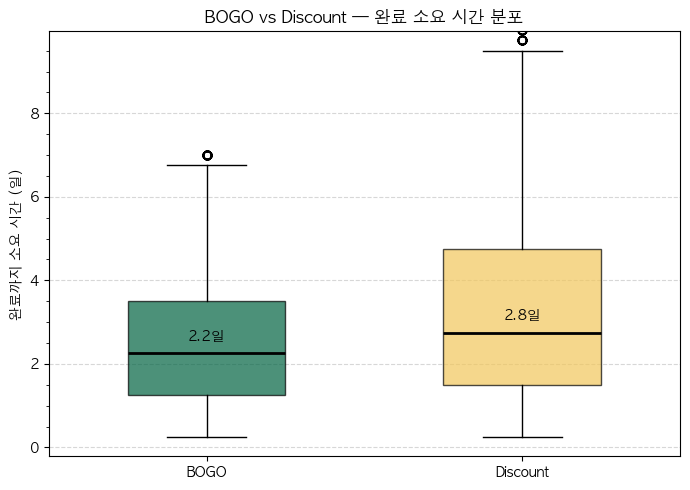

In [44]:
#BOGO vs Discount — 완료 소요 시간 분포
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plot_df = funnel[funnel['offer_type'].isin(['bogo', 'discount']) & funnel['is_completed'] & funnel['completed_with_prior_view']].copy()
plot_df['gap_days'] = plot_df['gap_to_complete'] / 24

fig, ax = plt.subplots(figsize=(7, 5))

groups = [
    plot_df.loc[plot_df['offer_type'] == 'bogo', 'gap_days'],
    plot_df.loc[plot_df['offer_type'] == 'discount', 'gap_days'],
]
bp = ax.boxplot(groups, labels=['BOGO', 'Discount'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

colors = ['#006241', '#F2C75C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 실제 whisker 끝값 기준으로 ylim 설정
whisker_bottoms = [w.get_ydata()[1] for w in bp['whiskers'][0::2]]
whisker_tops = [w.get_ydata()[1] for w in bp['whiskers'][1::2]]
margin = (max(whisker_tops) - min(whisker_bottoms)) * 0.05
ax.set_ylim(min(whisker_bottoms) - margin, max(whisker_tops) + margin)

ax.set_ylabel('완료까지 소요 시간 (일)')
ax.set_title('BOGO vs Discount — 완료 소요 시간 분포')
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 중앙값 텍스트 표시
for i, g in enumerate(groups, 1):
    ax.text(i, g.median() + margin * 0.5, f'{g.median():.1f}일',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [45]:
from scipy import stats

# #BOGO vs Discount — 열람 소요 시간 분포
bogo_view = funnel.loc[(funnel['offer_type'] == 'bogo') & funnel['is_viewed'], 'gap_to_view']
disc_view  = funnel.loc[(funnel['offer_type'] == 'discount') & funnel['is_viewed'], 'gap_to_view']

for name, s in [('bogo', bogo_view), ('discount', disc_view)]:
    print(f"{name} 열람 건수: {len(s):,}  중앙값: {s.median()/24:.1f}일  평균: {s.mean()/24:.1f}일")

u_stat, p_val = stats.mannwhitneyu(bogo_view, disc_view, alternative='two-sided')
n1, n2 = len(bogo_view), len(disc_view)
r = 1 - (2 * u_stat) / (n1 * n2)
print('')
print("=" *50)
print(f"Mann-Whitney U test (열람 속도)")
print("=" *50)
print(f" U={u_stat:.0f}, p={p_val:.2e}")
if p_val < 0.05:
    diff = (disc_view.median() - bogo_view.median()) / 24
    faster = 'bogo' if diff > 0 else 'discount'
    print(f"→ p < 0.05: {faster}가 {abs(diff):.1f}일 빠르게 열람됨")
else:
    print("→ p >= 0.05: 유의미한 차이 없음")

print(f"효과 크기 (rank-biserial r) = {r:.3f}")
print(f"→ {'작음 (|r|<0.1)' if abs(r)<0.1 else '중간 (0.1≤|r|<0.3)' if abs(r)<0.3 else '큰 편 (|r|≥0.3)'}")


bogo 열람 건수: 25,250  중앙값: 0.5일  평균: 1.0일
discount 열람 건수: 21,370  중앙값: 0.5일  평균: 1.1일

Mann-Whitney U test (열람 속도)
 U=263321120, p=6.28e-06
→ p < 0.05: discount가 0.0일 빠르게 열람됨
효과 크기 (rank-biserial r) = 0.024
→ 작음 (|r|<0.1)


In [46]:
# 열람 후 완료까지 걸리는 시간 분포
display(funnel[funnel['completed_with_prior_view']]
        .groupby('offer_type')['gap_view_to_complete']
        .median()
        .to_frame('중앙값(시간)')
        .style.format({'중앙값(시간)': '{:.1f}'}))


,중앙값(시간)
offer_type,
bogo,30.0
discount,42.0


[ 열람 후 완료까지 소요 시간 ]
  bogo: n=9,413  중앙값=1.2일  평균=1.7일
  discount: n=11,135  중앙값=1.8일  평균=2.4일
Mann-Whitney U: U=42782219, p=8.75e-115
효과 크기 r=0.184 → 중간


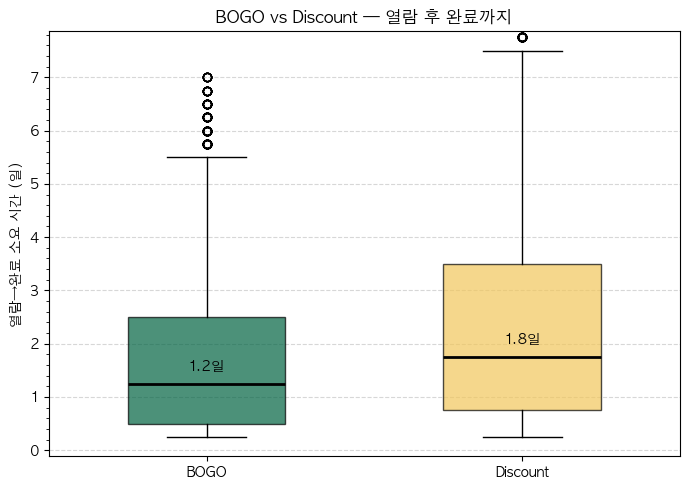

In [47]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()

# --- gap_view_to_complete 분포 (열람 후 완료까지) ---
print("[ 열람 후 완료까지 소요 시간 ]")
for otype, grp in bd.groupby('offer_type'):
    s = grp.loc[grp['completed_with_prior_view'], 'gap_view_to_complete'].dropna()
    print(f"  {otype}: n={len(s):,}  중앙값={s.median()/24:.1f}일  평균={s.mean()/24:.1f}일")

bogo_vc = bd.loc[(bd['offer_type'] == 'bogo') & bd['gap_view_to_complete'].notna() & bd['completed_with_prior_view'], 'gap_view_to_complete']
disc_vc = bd.loc[(bd['offer_type'] == 'discount') & bd['gap_view_to_complete'].notna() & bd['completed_with_prior_view'], 'gap_view_to_complete']
u, p = stats.mannwhitneyu(bogo_vc, disc_vc, alternative='two-sided')
n1, n2 = len(bogo_vc), len(disc_vc)
r = 1 - (2 * u) / (n1 * n2)
print(f"Mann-Whitney U: U={u:.0f}, p={p:.2e}")
print(f"효과 크기 r={r:.3f} → {'작음' if abs(r)<0.1 else '중간' if abs(r)<0.3 else '큰 편'}")

# 박스플롯
fig, ax = plt.subplots(figsize=(7, 5))
groups = [bogo_vc / 24, disc_vc / 24]
bp = ax.boxplot(groups, labels=['BOGO', 'Discount'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

colors = ['#006241', '#F2C75C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

whisker_bottoms = [w.get_ydata()[1] for w in bp['whiskers'][0::2]]
whisker_tops    = [w.get_ydata()[1] for w in bp['whiskers'][1::2]]
margin = (max(whisker_tops) - min(whisker_bottoms)) * 0.05
ax.set_ylim(min(whisker_bottoms) - margin, max(whisker_tops) + margin)

ax.set_ylabel('열람→완료 소요 시간 (일)')
ax.set_title('BOGO vs Discount — 열람 후 완료까지')
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 중앙값 텍스트 표시
for i, g in enumerate(groups, 1):
    ax.text(i, g.median() + margin * 0.5, f'{g.median():.1f}일',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


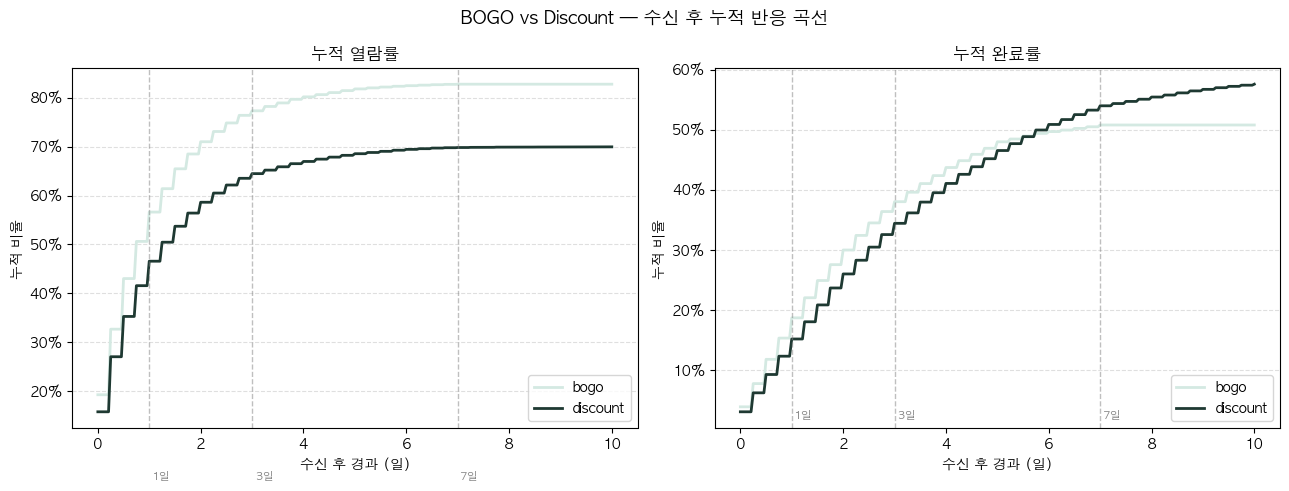

,열람_6h,완료_6h,열람_24h,완료_24h,열람_48h,완료_48h,열람_72h,완료_72h,열람_168h,완료_168h,유효기간내_완료
offer_type,,,,,,,,,,,
bogo,0.33,0.08,0.57,0.19,0.71,0.30,0.77,0.38,0.83,0.51,0.51
discount,0.27,0.06,0.47,0.15,0.59,0.26,0.64,0.34,0.70,0.54,0.58


,n,완료 건수,완료율(%),95%CI 하한(%),95%CI 상한(%)
열람 타이밍,,,,,
6h내,21758,9507,43.7,43.0,44.4
6~24h,16314,6138,37.6,36.9,38.4
24~48h,10147,3101,30.6,29.7,31.5
48~72h,4776,1157,24.2,23.0,25.5
72h+,3572,645,18.1,16.8,19.4


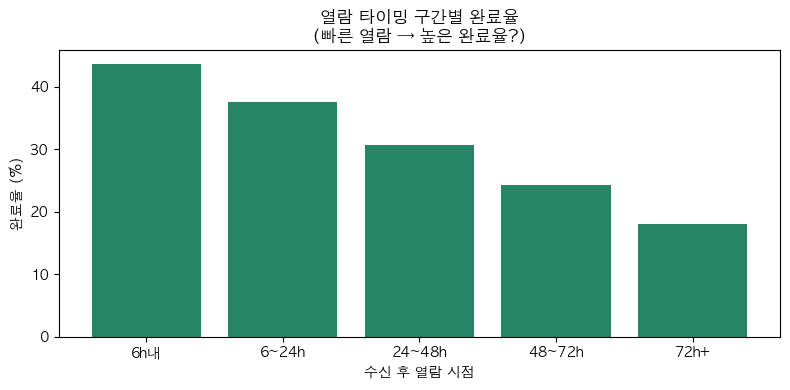

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()

# --- 누적 반응 곡선 ---
time_points = np.arange(0, 24 * 10 + 1, 1)
days = time_points / 24

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
colors = {'bogo': '#D4E9E2', 'discount': '#1E3932'}

for otype, grp in bd.groupby('offer_type'):
    n = len(grp)
    cum_view = [(grp['gap_to_view'].dropna() <= t).sum() / n for t in time_points]
    cum_comp = [(grp['gap_to_complete'].dropna() <= t).sum() / n for t in time_points]

    axes[0].plot(days, cum_view, label=otype, color=colors[otype], linewidth=2)
    axes[1].plot(days, cum_comp, label=otype, color=colors[otype], linewidth=2)

for ax, title in zip(axes, ['누적 열람률', '누적 완료률']):
    ax.set_xlabel('수신 후 경과 (일)')
    ax.set_ylabel('누적 비율')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.axvline(1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(7, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(1.05, 0.02, '1일', color='gray', fontsize=8)
    ax.text(3.05, 0.02, '3일', color='gray', fontsize=8)
    ax.text(7.05, 0.02, '7일', color='gray', fontsize=8)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('BOGO vs Discount — 수신 후 누적 반응 곡선', fontsize=13)
plt.tight_layout()
plt.show()

# --- 주요 시점별 반응률 테이블 ---
thresholds = [6, 24, 48, 72, 168]
rows = []
for otype, grp in bd.groupby('offer_type'):
    n = len(grp)
    row = {'offer_type': otype}
    for t in thresholds:
        row[f'열람_{t}h'] = (grp['gap_to_view'].dropna() <= t).sum() / n
        row[f'완료_{t}h'] = (grp['gap_to_complete'].dropna() <= t).sum() / n
    row['유효기간내_완료'] = (
        grp['is_completed'] & (grp['gap_to_complete'] <= grp['duration'].fillna(0) * 24)
    ).sum() / n
    rows.append(row)

summary = pd.DataFrame(rows).set_index('offer_type').round(2)
display(summary)

# --- 열람 타이밍 구간별 완료율 ---
viewed_df = funnel[funnel['is_viewed'] == True].copy()

bins = [-1, 6, 24, 48, 72, float('inf')]
labels = ['6h내', '6~24h', '24~48h', '48~72h', '72h+']
viewed_df['view_timing'] = pd.cut(viewed_df['gap_to_view'], bins=bins, labels=labels, right=True)

timing_summary = (
    viewed_df.groupby('view_timing', observed=True)
    .agg(
        n=('completed_with_prior_view', 'count'),
        completed=('completed_with_prior_view', 'sum')  # ← 미인지 완료 제외
    )
    .reset_index()
)
timing_summary['완료율(%)'] = (timing_summary['completed'] / timing_summary['n'] * 100).round(1)

# CI 계산
ci_rows = []
for _, row in timing_summary.iterrows():
    lo, hi = proportion_confint(int(row['completed']), int(row['n']), method='wilson')
    ci_rows.append({
        '열람 타이밍': row['view_timing'],
        'n': int(row['n']),
        '완료 건수': int(row['completed']),
        '완료율(%)': row['완료율(%)'],
        '95%CI 하한(%)': round(lo * 100, 1),
        '95%CI 상한(%)': round(hi * 100, 1),
    })

display(pd.DataFrame(ci_rows).set_index('열람 타이밍'))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(timing_summary['view_timing'].astype(str), timing_summary['완료율(%)'],
       color='#00704A', alpha=0.85)
ax.set_title('열람 타이밍 구간별 완료율\n(빠른 열람 → 높은 완료율?)', fontweight='bold')
ax.set_xlabel('수신 후 열람 시점')
ax.set_ylabel('완료율 (%)')
plt.tight_layout()
plt.show()

In [49]:
funnel[['offer_id','duration']].drop_duplicates()


,offer_id,duration
0,2906b810c7d4411798c6938adc9daaa5,7.0
1,3f207df678b143eea3cee63160fa8bed,4.0
2,5a8bc65990b245e5a138643cd4eb9837,3.0
3,f19421c1d4aa40978ebb69ca19b0e20d,5.0
4,fafdcd668e3743c1bb461111dcafc2a4,10.0
7,0b1e1539f2cc45b7b9fa7c272da2e1d7,10.0
8,2298d6c36e964ae4a3e7e9706d1fb8c2,7.0
11,9b98b8c7a33c4b65b9aebfe6a799e6d9,7.0
12,4d5c57ea9a6940dd891ad53e9dbe8da0,5.0
14,ae264e3637204a6fb9bb56bc8210ddfd,7.0


In [50]:
from scipy import stats
import numpy as np

bd_dur = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()
bd_dur['aware_completed'] = bd_dur['is_completed'] & bd_dur['completed_with_prior_view']

# --- duration 길이별 인지완료율 ---
dur_rate = (bd_dur.groupby(['offer_type', 'duration'])['aware_completed']
            .agg(['mean', 'count'])
            .rename(columns={'mean': '인지완료율', 'count': '건수'}))
display(dur_rate.style.format({'인지완료율': '{:.1%}', '건수': '{:,}'}))

# --- chi-square (offer_type별) ---
chi_rows = []
for otype, grp in bd_dur.groupby('offer_type'):
    ct = pd.crosstab(grp['duration'], grp['aware_completed'])
    if ct.shape[0] < 2:
        chi_rows.append({'offer_type': otype, 'chi2': '-', 'p': '-', 'V': '-', '유의여부': 'duration 값이 1개라 검정 불가'})
        continue
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    chi_rows.append({
        'offer_type': otype,
        'chi2': round(chi2, 1),
        'p': f'{p:.2e}',
        'V': round(v, 3),
        '유의여부': '유의' if p < 0.05 else '비유의',
    })

display(pd.DataFrame(chi_rows).set_index('offer_type'))

,chi2,p,V,유의여부
offer_type,,,,
bogo,271.3,5.85e-61,0.094,유의
discount,22.5,2.07e-06,0.027,유의


#### 수신 후 반응 집중 시점
---
- 열람: 24시간 내에 절반 이상 반응 (bogo 57%, discount 47%) — 이번 데이터에서 관측된 패턴
- 완료: 72시간까지 꾸준히 누적, 이후 증가폭 둔화
---
#### 초반 반응 속도
- bogo가 전 시점에서 열람/완료 모두 빠름 (6h 열람 33% vs 27%)
- 인지 완료율은 discount가 높음 (36% vs 31%) — bogo는 빨리 보지만 완료로 이어지지 않는 경향
---
#### 유효기간 내 완료 비율
- bogo 31%, discount 36%
- 대부분 7일(168h) 내에 완료 — 유효기간 연장보다 초반 24~72시간 내 전환 집중이 이번 데이터에서 관측됨


In [51]:
from scipy import stats

# --- 동일 오퍼 재수신 간격 vs 완료율 ---
multi = (funnel.sort_values(['customer_id', 'offer_id', 't_received'])
               .copy())
multi['aware_completed'] = multi['is_completed'] & multi['completed_with_prior_view']
multi['recv_gap'] = (multi.groupby(['customer_id', 'offer_id'])['t_received']
                          .diff())

multi_only = multi[multi['recv_gap'].notna()].copy()

# 기술통계
display(pd.DataFrame([{
    '재수신 인스턴스 수': f"{len(multi_only):,}건",
    '재수신 간격 중앙값': f"{multi_only['recv_gap'].median()/24:.1f}일",
    '재수신 간격 평균': f"{multi_only['recv_gap'].mean()/24:.1f}일",
}]))

# 간격 구간별 완료율
bins   = [0, 24, 72, 168, float('inf')]
labels = ['1일 이내', '1~3일', '3~7일', '7일 초과']
multi_only['gap_bin'] = pd.cut(multi_only['recv_gap'], bins=bins, labels=labels)

gap_summary = (multi_only.groupby('gap_bin', observed=True)['aware_completed']
               .agg(['mean', 'count'])
               .rename(columns={'mean': '인지완료율', 'count': '건수'}))
display(gap_summary.style.format({'인지완료율': '{:.1%}', '건수': '{:,}'}))

# 스피어만 상관
r, p = stats.spearmanr(multi_only['recv_gap'], multi_only['aware_completed'].astype(int))
display(pd.DataFrame([{
    'r': round(r, 3),
    'p': f'{p:.2e}',
    '해석': '유의미한 관계 있음' if p < 0.05 else '유의미한 관계 없음',
}]).set_index('r'))


,재수신 인스턴스 수,재수신 간격 중앙값,재수신 간격 평균
0,"12,989건",7.0일,10.5일


,인지완료율,건수
gap_bin,,
1~3일,25.1%,"1,921"
3~7일,26.5%,"4,604"
7일 초과,26.3%,"6,464"


,p,해석
r,,
0.009,2.99e-01,유의미한 관계 없음


In [52]:
# --- 몇 번째 수신에서 처음 열람하는가 (재발송 효과 검증) ---
fv = first_viewed_instance.copy()

# 분포
dist = fv['first_viewed_instance'].value_counts().sort_index()
dist_pct = dist / dist.sum() * 100

dist_df = pd.DataFrame({
    '수신 차수': [f"{inst}번째 수신" for inst in dist.index],
    '건수': dist.values,
    '비율(%)': dist_pct.values.round(1),
}).set_index('수신 차수')
display(dist_df.style.format({'건수': '{:,}', '비율(%)': '{:.1f}%'}))

re_send_view_rate = (fv['first_viewed_instance'] >= 2).mean()
display(pd.DataFrame([{
    '재발송 후 첫 열람 비율': f'{re_send_view_rate:.1%}',
    '첫 수신에서 바로 열람': f'{1 - re_send_view_rate:.1%}',
}]))

# 열람을 유도한 재발송 간격 분석
trigger = (
    multi
    .merge(fv.rename(columns={'first_viewed_instance': 'fv_inst'}),
           on=['customer_id', 'offer_id'])
    .query('instance_id == fv_inst and fv_inst >= 2')
    .dropna(subset=['recv_gap'])
    .copy()
)

display(pd.DataFrame([{
    '재발송 건수': f"{len(trigger):,}개",
    '간격 중앙값': f"{trigger['recv_gap'].median()/24:.1f}일",
    '간격 평균': f"{trigger['recv_gap'].mean()/24:.1f}일",
}]))

# 재발송 간격 구간별 분포
bins   = [0, 24, 72, 168, float('inf')]
labels = ['1일 이내', '1~3일', '3~7일', '7일 초과']
trigger['gap_bin'] = pd.cut(trigger['recv_gap'], bins=bins, labels=labels)

gap_dist = trigger['gap_bin'].value_counts().sort_index()
gap_pct  = gap_dist / gap_dist.sum() * 100
gap_df = pd.DataFrame({
    '건수': gap_dist.values,
    '비율(%)': gap_pct.values.round(1),
}, index=gap_dist.index)
display(gap_df.style.format({'건수': '{:,}', '비율(%)': '{:.1f}%'}))

# 재발송 간격 구간별 첫 열람 차수
inst_summary = (trigger.groupby('gap_bin', observed=True)['fv_inst']
                .agg(['median', 'mean', 'count'])
                .rename(columns={'median': '차수 중앙값', 'mean': '차수 평균', 'count': '건수'}))
display(inst_summary.style.format({'차수 중앙값': '{:.2f}', '차수 평균': '{:.2f}', '건수': '{:,}'}))

,건수,비율(%)
수신 차수,,
1번째 수신,"47,024",97.5%
2번째 수신,"1,146",2.4%
3번째 수신,42,0.1%
4번째 수신,1,0.0%


,재발송 후 첫 열람 비율,첫 수신에서 바로 열람
0,2.5%,97.5%


,재발송 건수,간격 중앙값,간격 평균
0,"1,189개",7.0일,9.6일


,건수,비율(%)
gap_bin,,
1일 이내,0,0.0%
1~3일,245,20.6%
3~7일,424,35.7%
7일 초과,520,43.7%


,차수 중앙값,차수 평균,건수
gap_bin,,,
1~3일,2.00,2.06,245
3~7일,2.00,2.05,424
7일 초과,2.00,2.01,520


In [53]:
funnel.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 't_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'is_viewed',
       'is_completed', 'completed_without_prior_view',
       'completed_with_prior_view', 'concurr', 'gap_view_to_complete',
       'reward', 'difficulty', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social',
       'channel_count', 'gender', 'age_group', 'income_group', 'join_year',
       'join_month', 'join_cohort'],
      dtype='str')

---
#### 📌 파트 3 인사이트 — 어떤 오퍼를 보내야 하는가

**오퍼 유형별 전환율**
- bogo는 열람률이 높지만(82.8%) 열람→완료 전환율이 낮음(43.3%) — 오퍼를 보긴 하나 조건 달성이 어려움
- discount는 열람률은 낮지만(70.0%) 한번 열람 시 완료율이 높음(57.7%) — 조건이 상대적으로 달성하기 쉬움

**난이도**
- 난이도가 높을수록 완료율 하락 (bogo/discount 모두 유의, p<0.05)
- **discount가 난이도에 훨씬 더 민감** — 로지스틱 회귀 상호작용항 유의 (p≈0, coef=+0.116)
- discount 난이도 20에서 완료율 17.0%로 급락 — 난이도 7(56.9%) 대비 40%p 가까이 하락
- bogo는 난이도 5(36.9%) → 10(34.9%), 2%p 차이로 난이도 영향 미미

**채널 (※ 채널 자체 효과와 고객 특성 혼재 가능, 인과 해석 주의)**
- discount는 mobile/social 채널 수신 그룹에서 완료율이 높게 관측됨 (mobile +31.2%p, social +36.3%p)
- bogo도 social 채널 수신 그룹에서 완료율이 높음 (+11.3%p) — 단, 채널별 고객 구성 차이가 반영됐을 수 있음

**기타**
- 완료의 약 30%는 prior view 로그가 확인되지 않은 완료 (bogo 29.4%, discount 30.0%) — 유형 간 차이 없음
---


---
#### 📌 파트 4 인사이트 — 어떤 간격으로 보내야 하는가

**완료/열람 속도**
- prior view 확인 완료자 기준 소요시간 분포가 bogo와 discount 간 유의미하게 다름 (Mann-Whitney p=1.37e-241, r=0.211 중간 효과) — bogo 완료자 중앙값이 더 짧음
- 열람 속도도 bogo가 더 빠름 — 단, 인지 완료율은 discount가 높음 (36% vs 31%)
- 열람 후 완료까지도 bogo가 더 빠름 (중앙값 약 1.25일 vs discount 1.75일)

**반응 집중 시점**
- 수신 후 24시간 내 열람이 집중 (bogo 57%, discount 47%) — 이번 데이터에서 관측된 패턴
- 완료는 72시간까지 꾸준히 누적, 이후 증가폭 둔화
- 인지 완료율: bogo 31%, discount 36% — 대부분 7일 내 완료

**유효기간**
- duration이 길다고 완료율이 높지 않음 (discount: 7일 37.8% > 10일 35.1%) — 이번 데이터에서 관측된 패턴
- bogo는 오히려 기간이 짧을수록 완료율 높음 (5일 35.2% > 7일 26.5%)

**재발송 효과**
- 재수신 간격 ↔ 완료율: 스피어만 r=0.013, p=0.138 → 유의미한 관계 없음
- 97.5%는 **첫 수신에서 바로 열람** — 재발송이 열람을 유도하는 경우는 2.5%에 불과
- 재발송 후 열람한 경우도 간격(1~3일 / 3~7일 / 7일 초과)과 무관하게 차수 중앙값 동일(2.0)

**발송 전략 시사점**
- 재발송 빈도·간격 조절보다 **첫 발송 품질(오퍼 내용, 채널 선택)** 이 핵심
- 수신 후 24~72시간 내 전환 집중이 이번 데이터에서 관측됨 — 유효기간 연장보다 초반 유도 전략 검토 여지 있음
---


### 어떤 고객 집단에게 보내야 하는가 - 세그먼트 분석

In [92]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportion_confint
import warnings
warnings.filterwarnings('ignore')

# --- age_gender, income은 funnel에 없으므로 full에서 추가 ---
for col in ['age_gender', 'income']:
    if col not in funnel.columns:
        extra = full[['customer_id', col]].drop_duplicates('customer_id')
        funnel = funnel.merge(extra, on='customer_id', how='left')

# --- funnel_clean: 누락 제거 ---
funnel_clean = funnel[
    (funnel['income_group'] != '누락') &
    (funnel['age_group'] != '누락') &
    (funnel['income'] != 0)
].copy()

# --- transaction 데이터 (상위 1% 제거) ---
tx_raw = full[full['event'] == 'transaction'].copy()
amount_upper = tx_raw['amount'].quantile(0.99)
tx = tx_raw[tx_raw['amount'] <= amount_upper].copy()
merge_cols = ['customer_id'] + [c for c in ['gender', 'age_group', 'income_group', 'join_year'] if c not in tx.columns]
cust_attr = funnel[merge_cols].drop_duplicates('customer_id')
tx = tx.merge(cust_attr, on='customer_id', how='left')

display(pd.DataFrame([{
    'amount 상위 1% 기준값': f"${amount_upper:.2f}",
    '제거 건수': f"{len(tx_raw)-len(tx):,}건",
    'funnel_clean 건수': f"{len(funnel_clean):,}건",
}]))

# 5대 지표 컬럼 설명
display(pd.DataFrame([{
    'view_rate':     '수신→열람',
    'complete_rate': '수신→완료',
    'view_cvr':      '열람→완료 (열람 선행)',
    'eff_cvr':       '완료 중 열람 선행 비율',
    'no_eff_cvr':    'prior view 미확인 완료 비율',
}], index=['설명']))


,amount 상위 1% 기준값,제거 건수,funnel_clean 건수
0,$40.02,"1,390건","66,501건"


,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
설명,수신→열람,수신→완료,열람→완료 (열람 선행),완료 중 열람 선행 비율,prior view 미확인 완료 비율


In [93]:
print("[ 소득 구간별 분석 ]")
inc_order = ['5만 미만', '5-7.5만', '7.5-10만', '10만 이상']
bd_clean = funnel_clean[funnel_clean['offer_type'].isin(['bogo', 'discount'])]

# 5대 지표
inc_m = funnel_metrics(bd_clean, 'income_group').set_index('income_group').reindex(inc_order)
display(inc_m.style.format({
    'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
    'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
    'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
    'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
}))

# 시간 지표
print("소득 구간별 시간 지표:")
time_m = (bd_clean.groupby('income_group')[['gap_to_view', 'gap_to_complete']]
          .mean().div(24)
          .rename(columns={'gap_to_view': '열람까지(일)', 'gap_to_complete': '완료까지(일)'})
          .reindex(inc_order))
display(time_m.style.format('{:.2f}'))

# chi-square (완료율)
bd_inc = bd_clean.copy()
bd_inc['aware_completed'] = bd_inc['is_completed'] & bd_inc['completed_with_prior_view']
ct_inc = pd.crosstab(bd_inc['income_group'], bd_inc['aware_completed'])
chi2_inc, p_inc, _, expected_inc = stats.chi2_contingency(ct_inc)
v_inc = np.sqrt(chi2_inc / (ct_inc.values.sum() * (min(ct_inc.shape)-1)))

display(pd.DataFrame([{
    '기대빈도 최솟값': f"{expected_inc.min():.1f} {'(>=5 OK)' if expected_inc.min()>=5 else '(<5 해석 주의)'}",
    'χ²': f"{chi2_inc:.2f}",
    'p': f"{p_inc:.2e}",
    'V': f"{v_inc:.3f}",
    '유의여부': '유의' if p_inc < 0.05 else '비유의',
}]))

# 거래금액: transaction-level
inc_tx = tx[tx['income_group'].isin(inc_order)].copy()
inc_amt = (inc_tx.groupby('income_group')['amount']
           .agg(['mean', 'median'])
           .rename(columns={'mean': '평균($)', 'median': '중앙값($)'})
           .reindex(inc_order))
display(inc_amt.style.format('{:.2f}'))

# 거래금액: customer-level
person_amt = inc_tx.groupby(['customer_id', 'income_group'])['amount'].mean().reset_index()
inc_person_amt = (person_amt.groupby('income_group')['amount']
                  .mean()
                  .rename('1인당 평균($)')
                  .reindex(inc_order)
                  .to_frame())
display(inc_person_amt.style.format('{:.2f}'))

# ANOVA + Kruskal-Wallis
groups_inc = [inc_tx[inc_tx['income_group']==i]['amount'].dropna().values
              for i in inc_order if len(inc_tx[inc_tx['income_group']==i]) > 0]
f_inc, p_anova_inc = stats.f_oneway(*groups_inc)
kw_inc, p_kw_inc   = stats.kruskal(*groups_inc)

display(pd.DataFrame([{
    'ANOVA F': f"{f_inc:.2f}",
    'ANOVA p': f"{p_anova_inc:.2e}",
    'Kruskal-Wallis H': f"{kw_inc:.2f}",
    'Kruskal-Wallis p': f"{p_kw_inc:.2e}",
    '일치여부': 'ANOVA 결과와 일치' if (p_anova_inc < 0.05) == (p_kw_inc < 0.05) else '불일치 — 비모수 기준 우선',
}]))

# Tukey HSD
tukey_df_data = inc_tx[['income_group', 'amount']].dropna()
tukey_inc = pairwise_tukeyhsd(tukey_df_data['amount'], tukey_df_data['income_group'], alpha=0.05)
tukey_df = pd.DataFrame(data=tukey_inc._results_table.data[1:], columns=tukey_inc._results_table.data[0])
sig = tukey_df[tukey_df['reject'] == True][['group1', 'group2', 'meandiff', 'p-adj']].copy()
sig['meandiff'] = sig['meandiff'].apply(lambda x: f"${float(x):.2f}")
sig['p-adj']    = sig['p-adj'].apply(lambda x: f"{float(x):.4f}")
sig = sig.rename(columns={'group1': '그룹1', 'group2': '그룹2', 'meandiff': '평균차이', 'p-adj': 'p값'})
display(sig.reset_index(drop=True) if len(sig) > 0 else pd.DataFrame([{'결과': '유의한 쌍 없음'}]))


[ 소득 구간별 분석 ]


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
income_group,,,,,,,,,,
5만 미만,"13,618","9,391","5,965","3,657","1,912",69.0%,43.8%,38.9%,61.3%,32.1%
5-7.5만,"23,152","18,076","13,741","8,766","3,772",78.1%,59.4%,48.5%,63.8%,27.5%
7.5-10만,"12,479","10,071","9,270","5,677","2,786",80.7%,74.3%,56.4%,61.2%,30.1%
10만 이상,"3,952","2,720","3,024","1,559","1,196",68.8%,76.5%,57.3%,51.6%,39.6%


소득 구간별 시간 지표:


,열람까지(일),완료까지(일)
income_group,,
5만 미만,1.14,2.90
5-7.5만,0.99,2.47
7.5-10만,0.97,2.33
10만 이상,1.29,2.43


,기대빈도 최솟값,χ²,p,V,유의여부
0,1460.4 (>=5 OK),1005.52,1.14e-217,0.137,유의


,평균($),중앙값($)
income_group,,
5만 미만,5.79,4.42
5-7.5만,10.90,10.38
7.5-10만,22.21,21.96
10만 이상,26.09,26.06


,1인당 평균($)
income_group,
5만 미만,5.35
5-7.5만,11.16
7.5-10만,22.32
10만 이상,26.02


,ANOVA F,ANOVA p,Kruskal-Wallis H,Kruskal-Wallis p,일치여부
0,36591.57,0.00e+00,52578.23,0.00e+00,ANOVA 결과와 일치


,그룹1,그룹2,평균차이,p값
0,10만 이상,5-7.5만,$-15.19,0.0000
1,10만 이상,5만 미만,$-20.30,0.0000
2,10만 이상,7.5-10만,$-3.88,0.0000
3,5-7.5만,5만 미만,$-5.11,0.0000
4,5-7.5만,7.5-10만,$11.31,0.0000
5,5만 미만,7.5-10만,$16.42,0.0000


In [94]:
# ─── 소득수준 × 오퍼유형 view_cvr / eff_cvr 비교표 ───
bd_inc = funnel_clean[funnel_clean['offer_type'].isin(['bogo','discount'])].copy()
bd_inc['aware_completed'] = bd_inc['is_completed'] & bd_inc['completed_with_prior_view']

rows = []
for g in inc_order:
    sub = bd_inc[bd_inc['income_group'] == g]
    row = {'소득구간': g}
    for ot in ['bogo', 'discount']:
        s = sub[sub['offer_type'] == ot]
        n_comp = int(s['is_completed'].sum())
        n_view = int(s['is_viewed'].sum())
        vc = s['aware_completed'].sum() / n_comp * 100 if n_comp > 0 else 0
        ec = s['aware_completed'].sum() / n_view * 100 if n_view > 0 else 0
        row[f'{ot} view_cvr'] = f"{vc:.1f}% (n={n_comp})"
        row[f'{ot} eff_cvr']  = f"{ec:.1f}% (n={n_view})"
    rows.append(row)

display(pd.DataFrame(rows).set_index('소득구간'))

,bogo view_cvr,bogo eff_cvr,discount view_cvr,discount eff_cvr
소득구간,,,,
5만 미만,58.3% (n=2607),28.3% (n=5379),63.6% (n=3358),53.3% (n=4012)
5-7.5만,62.3% (n=6506),41.5% (n=9767),65.1% (n=7235),56.7% (n=8309)
7.5-10만,61.2% (n=4500),52.8% (n=5217),61.3% (n=4770),60.2% (n=4854)
10만 이상,55.5% (n=1487),55.0% (n=1502),47.7% (n=1537),60.2% (n=1218)


In [95]:
# ─── 카이제곱: 소득수준 × eff_cvr / view_cvr ───
def chi_result_df(ct, label):
    chi2, p, _, expected = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1)))
    return {
        '기준': label,
        '기대빈도 최솟값': f"{expected.min():.1f} {'(>=5 OK)' if expected.min()>=5 else '(<5 해석 주의)'}",
        'χ²': f"{chi2:.2f}", 'p': f"{p:.2e}", 'V': f"{v:.3f}",
        '유의여부': '유의' if p < 0.05 else '비유의',
        '효과크기': '강함' if v >= 0.3 else '중간' if v >= 0.1 else '약함',
    }

bd_inc_view = bd_inc[bd_inc['is_viewed'] == True]
ct_eff = pd.crosstab(bd_inc_view['income_group'], bd_inc_view['completed_with_prior_view'])

bd_inc_comp = bd_inc[bd_inc['is_completed'] == True]
ct_view = pd.crosstab(bd_inc_comp['income_group'], bd_inc_comp['completed_with_prior_view'])

display(pd.DataFrame([
    chi_result_df(ct_eff,  'eff_cvr (열람 건 기준)'),
    chi_result_df(ct_view, 'view_cvr (완료 건 기준)'),
]).set_index('기준'))

,기대빈도 최솟값,χ²,p,V,유의여부,효과크기
기준,,,,,,
eff_cvr (열람 건 기준),1328.2 (>=5 OK),675.85,3.63e-146,0.130,유의,중간
view_cvr (완료 건 기준),1166.2 (>=5 OK),157.09,7.80e-34,0.070,유의,약함


In [96]:
# ─── 로지스틱 회귀: 소득수준 × 오퍼유형 → eff_cvr / view_cvr ───
label_map_inc = {
    'Intercept': 'Intercept',
    'C(income_group, Treatment("5-7.5만"))[T.5만 미만]':  '5만 미만 (vs 5-7.5만)',
    'C(income_group, Treatment("5-7.5만"))[T.7.5-10만]': '7.5-10만 (vs 5-7.5만)',
    'C(income_group, Treatment("5-7.5만"))[T.10만 이상]': '10만 이상 (vs 5-7.5만)',
    'C(offer_type)[T.discount]':                          'discount (vs bogo)',
    'C(income_group, Treatment("5-7.5만"))[T.5만 미만]:C(offer_type)[T.discount]':  '5만 미만 × discount',
    'C(income_group, Treatment("5-7.5만"))[T.7.5-10만]:C(offer_type)[T.discount]': '7.5-10만 × discount',
    'C(income_group, Treatment("5-7.5만"))[T.10만 이상]:C(offer_type)[T.discount]': '10만 이상 × discount',
}

def logit_or_income(data, dep_var, label_map):
    m = smf.logit(
        f'{dep_var} ~ C(income_group, Treatment("5-7.5만")) * C(offer_type)',
        data=data
    ).fit(disp=False)
    coef = m.summary2().tables[1][['Coef.', 'P>|z|']].copy()
    coef['OR'] = np.exp(coef['Coef.']).round(2)
    coef['p']  = coef['P>|z|'].apply(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')
    coef['유의'] = coef['P>|z|'].apply(lambda x: '★' if x < 0.05 else '')
    coef.index = [label_map.get(i, i) for i in coef.index]
    return coef[['OR', 'p', '유의']].drop(index='Intercept')

# eff_cvr (열람 건 기준)
bd_inc_view = bd_inc[bd_inc['is_viewed'] == True].copy()
bd_inc_view['eff_cvr_int'] = bd_inc_view['completed_with_prior_view'].astype(int)
print("[ eff_cvr (열람 건 기준) ]")
display(logit_or_income(bd_inc_view, 'eff_cvr_int', label_map_inc))

# view_cvr (완료 건 기준)
bd_inc_comp = bd_inc[bd_inc['is_completed'] == True].copy()
bd_inc_comp['view_cvr_int'] = bd_inc_comp['completed_with_prior_view'].astype(int)
print("[ view_cvr (완료 건 기준) ]")
display(logit_or_income(bd_inc_comp, 'view_cvr_int', label_map_inc))

[ eff_cvr (열람 건 기준) ]


,OR,p,유의
10만 이상 (vs 5-7.5만),1.72,<0.001,★
5만 미만 (vs 5-7.5만),0.56,<0.001,★
7.5-10만 (vs 5-7.5만),1.58,<0.001,★
discount (vs bogo),1.85,<0.001,★
10만 이상 × discount,0.67,<0.001,★
5만 미만 × discount,1.57,<0.001,★
7.5-10만 × discount,0.73,<0.001,★


[ view_cvr (완료 건 기준) ]


,OR,p,유의
10만 이상 (vs 5-7.5만),0.76,<0.001,★
5만 미만 (vs 5-7.5만),0.85,<0.001,★
7.5-10만 (vs 5-7.5만),0.95,0.244,
discount (vs bogo),1.13,<0.001,★
10만 이상 × discount,0.65,<0.001,★
5만 미만 × discount,1.11,0.115,
7.5-10만 × discount,0.89,0.031,★


In [97]:
print("[ 성별 분석 ]")
gender_order = ['M', 'F']
bd_clean = funnel_clean[funnel_clean['offer_type'].isin(['bogo', 'discount'])]

# 5대 지표
gen_m = funnel_metrics(bd_clean, 'gender').set_index('gender').reindex(gender_order)
print("성별 5대 지표:")
display(gen_m.style.format({
    'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
    'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
    'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
    'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
}))

# 시간 지표
print("성별 시간 지표:")
time_m = (bd_clean.groupby('gender')[['gap_to_view', 'gap_to_complete']]
          .mean().div(24)
          .rename(columns={'gap_to_view': '열람까지(일)', 'gap_to_complete': '완료까지(일)'})
          .reindex(gender_order))
display(time_m.style.format('{:.2f}'))


[ 성별 분석 ]
성별 5대 지표:


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
gender,,,,,,,,,,
M,"30,562","22,881","16,210","10,265","4,688",74.9%,53.0%,44.9%,63.3%,28.9%
F,"21,918","16,765","15,297","9,067","4,871",76.5%,69.8%,54.1%,59.3%,31.8%


성별 시간 지표:


,열람까지(일),완료까지(일)
gender,,
M,1.04,2.63
F,1.05,2.38


In [98]:
# ─── 성별 × 오퍼유형 view_cvr / eff_cvr 비교표 ───
bd_g = funnel_clean[funnel_clean['offer_type'].isin(['bogo','discount']) & funnel_clean['gender'].isin(['M','F'])].copy()
bd_g['aware_completed'] = bd_g['is_completed'] & bd_g['completed_with_prior_view']

rows = []
for g in ['M', 'F']:
    sub = bd_g[bd_g['gender'] == g]
    row = {'성별': g}
    for ot in ['bogo', 'discount']:
        s = sub[sub['offer_type'] == ot]
        n_comp = int(s['is_completed'].sum())
        n_view = int(s['is_viewed'].sum())
        vc = s['aware_completed'].sum() / n_comp * 100 if n_comp > 0 else 0
        ec = s['aware_completed'].sum() / n_view * 100 if n_view > 0 else 0
        row[f'{ot} view_cvr'] = f"{vc:.1f}% (n={n_comp})"
        row[f'{ot} eff_cvr']  = f"{ec:.1f}% (n={n_view})"
    rows.append(row)

display(pd.DataFrame(rows).set_index('성별'))

,bogo view_cvr,bogo eff_cvr,discount view_cvr,discount eff_cvr
성별,,,,
M,60.9% (n=7425),36.2% (n=12485),65.3% (n=8785),55.2% (n=10396)
F,60.2% (n=7434),49.3% (n=9065),58.4% (n=7863),59.7% (n=7700)


In [99]:
# ─── 카이제곱: 성별 × eff_cvr / view_cvr ───
def chi_result_df(ct, label):
    chi2, p, _, expected = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1)))
    return {
        '기준': label,
        '기대빈도 최솟값': f"{expected.min():.1f} {'(>=5 OK)' if expected.min()>=5 else '(<5 해석 주의)'}",
        'χ²': f"{chi2:.2f}", 'p': f"{p:.2e}", 'V': f"{v:.3f}",
        '유의여부': '유의' if p < 0.05 else '비유의',
        '효과크기': '강함' if v >= 0.3 else '중간' if v >= 0.1 else '약함',
    }

bd_g_view = bd_g[bd_g['is_viewed'] == True]
ct_eff = pd.crosstab(bd_g_view['gender'], bd_g_view['completed_with_prior_view'])

bd_g_comp = bd_g[bd_g['is_completed'] == True]
ct_view = pd.crosstab(bd_g_comp['gender'], bd_g_comp['completed_with_prior_view'])

display(pd.DataFrame([
    chi_result_df(ct_eff,  'eff_cvr (열람 건 기준)'),
    chi_result_df(ct_view, 'view_cvr (완료 건 기준)'),
]).set_index('기준'))

,기대빈도 최솟값,χ²,p,V,유의여부,효과크기
기준,,,,,,
eff_cvr (열람 건 기준),8174.9 (>=5 OK),328.86,1.70e-73,0.091,유의,약함
view_cvr (완료 건 기준),5911.1 (>=5 OK),54.33,1.70e-13,0.042,유의,약함


In [100]:
# ─── 로지스틱 회귀: 성별 × 오퍼유형 → eff_cvr / view_cvr ───
label_map_g = {
    'Intercept': 'Intercept',
    'C(gender, Treatment("M"))[T.F]': '여성 (vs 남성)',
    'C(offer_type)[T.discount]': 'discount (vs bogo)',
    'C(gender, Treatment("M"))[T.F]:C(offer_type)[T.discount]': '여성 × discount',
}

def logit_or_gender(data, dep_var, label_map):
    m = smf.logit(
        f'{dep_var} ~ C(gender, Treatment("M")) * C(offer_type)',
        data=data
    ).fit(disp=False)
    coef = m.summary2().tables[1][['Coef.', 'P>|z|']].copy()
    coef['OR'] = np.exp(coef['Coef.']).round(2)
    coef['p']  = coef['P>|z|'].apply(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')
    coef['유의'] = coef['P>|z|'].apply(lambda x: '★' if x < 0.05 else '')
    coef.index = [label_map.get(i, i) for i in coef.index]
    return coef[['OR', 'p', '유의']].drop(index='Intercept')

# eff_cvr (열람 건 기준)
bd_g_view = bd_g[bd_g['is_viewed'] == True].copy()
bd_g_view['eff_cvr_int'] = bd_g_view['completed_with_prior_view'].astype(int)
print("[ eff_cvr (열람 건 기준) ]")
display(logit_or_gender(bd_g_view, 'eff_cvr_int', label_map_g))

# view_cvr (완료 건 기준)
bd_g_comp = bd_g[bd_g['is_completed'] == True].copy()
bd_g_comp['view_cvr_int'] = bd_g_comp['completed_with_prior_view'].astype(int)
print("[ view_cvr (완료 건 기준) ]")
display(logit_or_gender(bd_g_comp, 'view_cvr_int', label_map_g))

[ eff_cvr (열람 건 기준) ]


,OR,p,유의
여성 (vs 남성),1.71,<0.001,★
discount (vs bogo),2.17,<0.001,★
여성 × discount,0.70,<0.001,★


[ view_cvr (완료 건 기준) ]


,OR,p,유의
여성 (vs 남성),0.97,0.327,
discount (vs bogo),1.21,<0.001,★
여성 × discount,0.77,<0.001,★


In [101]:
# 오퍼 유형별 성별 완료율 + 95% CI → DataFrame
print('')
print("오퍼 유형별 성별 완료율 + 95% CI:")
ci_rows = []
for ot in ['bogo', 'discount']:
    sub = bd_g[bd_g['offer_type']==ot]
    for g in ['F', 'M']:
        g_sub = sub[sub['gender']==g]
        n, k = len(g_sub), g_sub['aware_completed'].sum()
        lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
        ci_rows.append({
            'offer_type': ot,
            'gender': g,
            '완료율': f"{k/n*100:.1f}%",
            'CI_low': f"{lo*100:.1f}%",
            'CI_high': f"{hi*100:.1f}%",
            'n': n,
        })
pd.DataFrame(ci_rows).set_index(['offer_type', 'gender'])



오퍼 유형별 성별 완료율 + 95% CI:


완료율 CI_low CI_high      n
offer_type gender                             
bogo       F       40.7%  39.8%   41.7%  10975
           M       29.8%  29.0%   30.5%  15208
discount   F       42.0%  41.1%   42.9%  10943
           M       37.4%  36.6%   38.2%  15354

In [102]:
print("[ 연령대 분석 ]")
age_order = ['20대 미만', '20대', '30대', '40대', '50대', '60대 이상']
bd_clean = funnel_clean[funnel_clean['offer_type'].isin(['bogo', 'discount'])]

# 5대 지표
age_m = funnel_metrics(bd_clean, 'age_group').set_index('age_group').reindex(age_order)
print("연령대별 5대 지표:")
display(age_m.style.format({
    'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
    'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
    'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
    'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
}))

# 시간 지표
print("연령대별 시간 지표:")
time_m = (bd_clean.groupby('age_group')[['gap_to_view', 'gap_to_complete']]
          .mean().div(24)
          .rename(columns={'gap_to_view': '열람까지(일)', 'gap_to_complete': '완료까지(일)'})
          .reindex(age_order))
display(time_m.style.format('{:.2f}'))


[ 연령대 분석 ]
연령대별 5대 지표:


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
age_group,,,,,,,,,,
20대 미만,722,510,315,188,111,70.6%,43.6%,36.9%,59.7%,35.2%
20대,"4,997","3,496","2,347","1,391",790,70.0%,47.0%,39.8%,59.3%,33.7%
30대,"5,515","4,013","2,960","1,845",867,72.8%,53.7%,46.0%,62.3%,29.3%
40대,"8,241","6,537","4,788","3,160","1,188",79.3%,58.1%,48.3%,66.0%,24.8%
50대,"12,692","9,649","8,161","4,908","2,532",76.0%,64.3%,50.9%,60.1%,31.0%
60대 이상,"21,034","16,053","13,429","8,167","4,178",76.3%,63.8%,50.9%,60.8%,31.1%


연령대별 시간 지표:


,열람까지(일),완료까지(일)
age_group,,
20대 미만,1.12,2.81
20대,1.12,2.77
30대,1.04,2.55
40대,0.97,2.48
50대,1.08,2.46
60대 이상,1.03,2.48


In [103]:
# ─── 연령대 × 오퍼유형 view_cvr / eff_cvr 비교표 ───
bd_a = funnel_clean[funnel_clean['offer_type'].isin(['bogo','discount']) & funnel_clean['age_group'].isin(age_order)].copy()
bd_a['aware_completed'] = bd_a['is_completed'] & bd_a['completed_with_prior_view']

rows = []
for g in age_order:
    sub = bd_a[bd_a['age_group'] == g]
    row = {'연령대': g}
    for ot in ['bogo', 'discount']:
        s = sub[sub['offer_type'] == ot]
        n_comp = int(s['is_completed'].sum())
        n_view = int(s['is_viewed'].sum())
        vc = s['aware_completed'].sum() / n_comp * 100 if n_comp > 0 else 0
        ec = s['aware_completed'].sum() / n_view * 100 if n_view > 0 else 0
        row[f'{ot} view_cvr'] = f"{vc:.1f}% (n={n_comp})"
        row[f'{ot} eff_cvr']  = f"{ec:.1f}% (n={n_view})"
    rows.append(row)

display(pd.DataFrame(rows).set_index('연령대'))

,bogo view_cvr,bogo eff_cvr,discount view_cvr,discount eff_cvr
연령대,,,,
20대 미만,56.4% (n=140),25.8% (n=306),62.3% (n=175),53.4% (n=204)
20대,57.4% (n=1046),30.1% (n=1992),60.8% (n=1301),52.6% (n=1504)
30대,60.3% (n=1339),36.6% (n=2202),64.0% (n=1621),57.3% (n=1811)
40대,64.1% (n=2295),41.1% (n=3579),67.8% (n=2493),57.1% (n=2958)
50대,59.0% (n=3933),44.8% (n=5183),61.2% (n=4228),57.9% (n=4466)
60대 이상,61.1% (n=6347),45.1% (n=8603),60.6% (n=7082),57.6% (n=7450)


In [104]:
# ─── 카이제곱: 연령대 × eff_cvr / view_cvr ───
def chi_result_df(ct, label):
    chi2, p, _, expected = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1)))
    return {
        '기준': label,
        '기대빈도 최솟값': f"{expected.min():.1f} {'(>=5 OK)' if expected.min()>=5 else '(<5 해석 주의)'}",
        'χ²': f"{chi2:.2f}", 'p': f"{p:.2e}", 'V': f"{v:.3f}",
        '유의여부': '유의' if p < 0.05 else '비유의',
        '효과크기': '강함' if v >= 0.3 else '중간' if v >= 0.1 else '약함',
    }

# eff_cvr: 열람 건 기준
bd_a_view = bd_a[bd_a['is_viewed'] == True]
ct_eff = pd.crosstab(bd_a_view['age_group'], bd_a_view['completed_with_prior_view'])

# view_cvr: 완료 건 기준
bd_a_comp = bd_a[bd_a['is_completed'] == True]
ct_view = pd.crosstab(bd_a_comp['age_group'], bd_a_comp['completed_with_prior_view'])

display(pd.DataFrame([
    chi_result_df(ct_eff,  'eff_cvr (열람 건 기준)'),
    chi_result_df(ct_view, 'view_cvr (완료 건 기준)'),
]).set_index('기준'))

,기대빈도 최솟값,χ²,p,V,유의여부,효과크기
기준,,,,,,
eff_cvr (열람 건 기준),249.0 (>=5 OK),200.20,2.57e-41,0.071,유의,약함
view_cvr (완료 건 기준),121.5 (>=5 OK),56.10,7.75e-11,0.042,유의,약함


In [105]:
# ─── 로지스틱 회귀: 연령대 × 오퍼유형 → eff_cvr / view_cvr ───
label_map_a = {
    'Intercept': 'Intercept',
    'C(age_group, Treatment("30대"))[T.20대 미만]': '20대 미만 (vs 30대)',
    'C(age_group, Treatment("30대"))[T.20대]':     '20대 (vs 30대)',
    'C(age_group, Treatment("30대"))[T.40대]':     '40대 (vs 30대)',
    'C(age_group, Treatment("30대"))[T.50대]':     '50대 (vs 30대)',
    'C(age_group, Treatment("30대"))[T.60대 이상]': '60대 이상 (vs 30대)',
    'C(offer_type)[T.discount]':                   'discount (vs bogo)',
    'C(age_group, Treatment("30대"))[T.20대 미만]:C(offer_type)[T.discount]': '20대 미만 × discount',
    'C(age_group, Treatment("30대"))[T.20대]:C(offer_type)[T.discount]':     '20대 × discount',
    'C(age_group, Treatment("30대"))[T.40대]:C(offer_type)[T.discount]':     '40대 × discount',
    'C(age_group, Treatment("30대"))[T.50대]:C(offer_type)[T.discount]':     '50대 × discount',
    'C(age_group, Treatment("30대"))[T.60대 이상]:C(offer_type)[T.discount]': '60대 이상 × discount',
}

def logit_or_table(data, dep_var, label_map):
    m = smf.logit(
        f'{dep_var} ~ C(age_group, Treatment("30대")) * C(offer_type)',
        data=data
    ).fit(disp=False)
    coef = m.summary2().tables[1][['Coef.', 'P>|z|']].copy()
    coef['OR'] = np.exp(coef['Coef.']).round(2)
    coef['p']  = coef['P>|z|'].apply(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')
    coef['유의'] = coef['P>|z|'].apply(lambda x: '★' if x < 0.05 else '')
    coef.index = [label_map.get(i, i) for i in coef.index]
    return coef[['OR', 'p', '유의']].drop(index='Intercept')

# eff_cvr (열람 건 기준)
bd_a_view = bd_a[bd_a['is_viewed'] == True].copy()
bd_a_view['eff_cvr_int'] = bd_a_view['completed_with_prior_view'].astype(int)
print("[ eff_cvr (열람 건 기준) ]")
display(logit_or_table(bd_a_view, 'eff_cvr_int', label_map_a))

# view_cvr (완료 건 기준)
bd_a_comp = bd_a[bd_a['is_completed'] == True].copy()
bd_a_comp['view_cvr_int'] = bd_a_comp['completed_with_prior_view'].astype(int)
print("[ view_cvr (완료 건 기준) ]")
display(logit_or_table(bd_a_comp, 'view_cvr_int', label_map_a))

[ eff_cvr (열람 건 기준) ]


,OR,p,유의
20대 (vs 30대),0.75,<0.001,★
20대 미만 (vs 30대),0.60,<0.001,★
40대 (vs 30대),1.20,<0.001,★
50대 (vs 30대),1.40,<0.001,★
60대 이상 (vs 30대),1.42,<0.001,★
discount (vs bogo),2.32,<0.001,★
20대 × discount,1.11,0.283,
20대 미만 × discount,1.42,0.083,
40대 × discount,0.82,0.018,★
50대 × discount,0.73,<0.001,★


[ view_cvr (완료 건 기준) ]


,OR,p,유의
20대 (vs 30대),0.89,0.152,
20대 미만 (vs 30대),0.85,0.378,
40대 (vs 30대),1.17,0.023,★
50대 (vs 30대),0.95,0.410,
60대 이상 (vs 30대),1.03,0.579,
discount (vs bogo),1.17,0.035,★
20대 × discount,0.98,0.875,
20대 미만 × discount,1.09,0.733,
40대 × discount,1.01,0.948,
50대 × discount,0.93,0.446,


In [106]:
print("[연령×성별 완료율 ]")

age_gender_order = [
    '20세 미만 남성', '20세 미만 여성',
    '20대 남성', '20대 여성', '30대 남성', '30대 여성',
    '40대 남성', '40대 여성', '50대 남성', '50대 여성',
    '60대 남성', '60대 여성', '60+ 남성', '60+ 여성',
]

bd_ag = funnel_clean[
    funnel_clean['offer_type'].isin(['bogo','discount']) &
    funnel_clean['age_gender'].isin(age_gender_order)
].copy()
bd_ag['aware_completed'] = bd_ag['is_completed'] & bd_ag['completed_with_prior_view']

rate_ag = bd_ag.groupby(['age_gender','offer_type'])['aware_completed'].agg(rate='mean', n='count').reset_index()
rate_ag['rate'] = rate_ag['rate'] * 100

# 완료율 pivot (n<100 표본 부족 표시)
pivot_ag = rate_ag.pivot(index= 'age_gender',
                          columns='offer_type', values='rate')
n_pivot = rate_ag.pivot(index='age_gender', columns='offer_type', values='n')

def fmt(ag, ot):
    n = n_pivot.loc[ag, ot] if ot in n_pivot.columns and ag in n_pivot.index else 0
    r = rate_ag.loc[(rate_ag['age_gender']==ag) & (rate_ag['offer_type']==ot), 'rate']
    if n < 100:
        return f"표본 부족(n={int(n)})"
    return f"{r.values[0]:.1f}% (n={int(n)})" if len(r) else "-"

result_ag = pd.DataFrame(
    {ot: [fmt(ag, ot) for ag in age_gender_order] for ot in ['bogo', 'discount']},
    index=age_gender_order
)
result_ag.index.name = 'age_gender'
display(result_ag)

# chi-square (n>=100 그룹만)
n_ag = rate_ag.pivot(index='age_gender', columns='offer_type', values='n')
valid_ag = [
    ag for ag in age_gender_order
    if ag in n_ag.index and all(n_ag.loc[ag, ot] >= 100 for ot in ['bogo','discount'] if ot in n_ag.columns)
]
bd_ag_valid = bd_ag[bd_ag['age_gender'].isin(valid_ag)]
ct_ag = pd.crosstab(bd_ag_valid['age_gender'], bd_ag_valid['aware_completed'])
chi2_ag, p_ag, _, expected_ag = stats.chi2_contingency(ct_ag)
v_ag = np.sqrt(chi2_ag / (ct_ag.values.sum() * (min(ct_ag.shape)-1)))

chi_result = pd.DataFrame([{
    'n≥100 그룹 수': len(valid_ag),
    '기대빈도 최솟값': f"{expected_ag.min():.1f} {'(>=5 OK)' if expected_ag.min()>=5 else '(<5 해석 주의)'}",
    'χ²': f"{chi2_ag:.2f}",
    'p': f"{p_ag:.2e}",
    'V': f"{v_ag:.3f}",
    '유의여부': '유의' if p_ag<0.05 else '비유의',
}])
display(chi_result)


[연령×성별 완료율 ]


,bogo,discount
age_gender,,
20세 미만 남성,17.3% (n=294),34.8% (n=270)
20세 미만 여성,표본 부족(n=87),표본 부족(n=71)
20대 남성,20.5% (n=1687),29.4% (n=1816)
20대 여성,33.6% (n=736),35.7% (n=701)
30대 남성,24.6% (n=1795),35.0% (n=1874)
30대 여성,39.8% (n=876),40.9% (n=891)
40대 남성,30.5% (n=2626),39.1% (n=2505)
40대 여성,42.7% (n=1495),45.4% (n=1484)
50대 남성,33.0% (n=3455),39.2% (n=3445)


,n≥100 그룹 수,기대빈도 최솟값,χ²,p,V,유의여부
0,13,207.9 (>=5 OK),569.41,3.58e-114,0.104,유의


---
#### 📌 파트 1 인사이트 — 어떤 고객 집단에게 보내야 하는가

**소득**
- 소득↑ → 인지 완료율↑ 뚜렷 (43.8% → 76.5%), open_rate는 중간 소득이 더 높음
- 거래금액도 소득과 비례 ($5.35 → $26.02), transaction/customer-level 모두 일치 → heavy buyer 왜곡 없음
- 10만 이상은 open_rate가 낮은데(68.8%) 인지 완료율은 최고 → 오퍼 조건을 의식적으로 달성하는 충성 고객층 (단, unaware 완료율도 39.6%로 최고)

**성별**
- 여성이 남성보다 완료율 일관되게 높음 (F 69.8% vs M 53.0%), 오퍼 유형 관계없이
- bogo 남녀 차이가 discount보다 큼 → 남성은 특히 bogo 달성이 어려움

**연령대**
- 나이↑ → 완료율↑ 경향 (43.6% → 63.8%)
- 젊은 층일수록 discount가 bogo보다 훨씬 유리 (20대 미만 차이 +14.6%p, 50대 +4.2%p)

**연령×성별**
- 모든 연령대에서 여성 > 남성
- 20대 남성 bogo 23.5%로 최저 → 핵심 취약 세그먼트

**가입년도**
- 2016년 가입자가 완료율 최고(81.6%), 2018년 최저(38.5%) — 코호트 간 격차 큼 (V=0.311 강한 효과)
- 2013~2014년은 거래금액이 낮음 ($5.75) — 초기 가입자가 소액 구매자
---


누구에게 → 고소득 + 중간 소득 여성 + 40~60대<br>
어떤 오퍼를 →<br>
 - 고소득: discount (unaware_rate 높아 오퍼 없이도 완료 → 인지 효과 극대화) 
 - 중간 소득 여성·40~60대: bogo(빠른 반응) or discount(높은 완료율)<br>

어떤 간격으로 → 수신 후 24시간 내 열람 유도, 72시간 내 완료 집중<br>